In [19]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

In [20]:
df = pd.read_csv("financial_loan.csv")
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11-07-2021,16-05-2021,16-05-2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11-10-2021,16-04-2021,16-05-2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11-09-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11-10-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,11-07-2021,16-05-2021,16-05-2021,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [21]:
df.shape
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='str')

In [22]:
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst=True)
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], dayfirst=True)
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], dayfirst=True)
df['next_payment_date'] = pd.to_datetime(df['next_payment_date'], dayfirst=True)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  str           
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [30]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## Total Loan applications

In [26]:
total_loan_application = df['id'].count()
total_loan_application

np.int64(38576)

## MTD total Applications

In [27]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month =  latest_issue_date.month

mtd_data = df[(
    df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)
]
mtd_loan_application = mtd_data['id'].count()
print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_application}")

MTD Loan Applications(for December 2021): 4314


## Total Funded Amount

In [28]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("total funded amount: ${:.2f}M ".format(total_funded_amount_millions))

total funded amount: $435.76M 


## MTD - Total Funded Amount

In [ ]:
# MTD Total Funded Amount (December)

MTD_Total_Funded_Amount = df[df['issue_date'].dt.month == 12]['loan_amount'].sum()
print("total funded amount: ${:.2f}M ".format(MTD_Total_Funded_Amount / 1000000))

total funded amount: $53.98M 


## Total Amount Recieved

In [ ]:
# Total Amount Collected
Total_Amount_Collected = df['total_payment'].sum()

print("Total Amount Collected: ${:.2f}M".format(Total_Amount_Collected / 1000000))

Total Amount Collected: $473.07M


## MTD - Total Amount Recieved

In [35]:
# MTD Total Amount Received (December)
MTD_Total_Amount_Received = df[df['issue_date'].dt.month == 12]['total_payment'].sum()

print("MTD Total Amount Received: ${:.2f}M".format(MTD_Total_Amount_Received / 1000000))


MTD Total Amount Received: $58.07M


### Avg Interest Rate

In [45]:
Avg_Int_Rate = df['int_rate'].mean() * 100
print("Avg Interest Rate: {:.2f}%". format(Avg_Int_Rate) )

Avg Interest Rate: 12.05%


## MTD - Total Avg Interest Rate

In [46]:
MTD_Avg_Rate = df[df['issue_date'].dt.month == 12]['int_rate'].mean() * 100
print("Avg Interest Rate: {:.2f}%". format(MTD_Avg_Rate) )


Avg Interest Rate: 12.36%


## Avg Debt-To-Income Ratio(DTI)

In [ ]:
Avg_Dti_Rat = df['dti'].mean()*100
print("Avg DTI Interest Rate: {:.2f}%". format(Avg_Dti_Rat) )

Avg DTI Interest Rate: 13.33%


## Good Loan Matrix

In [61]:
good_loan = df[ df['loan_status'].isin(['Fully Paid', 'Current'])]
good_loan_applications = good_loan['id'].count()
good_loan_funded_amount = good_loan['loan_amount'].sum()  / 1000000
good_loan_received = good_loan['total_payment'].sum() / 1000000
good_loan_percentage = (good_loan_applications/total_loan_application) * 100

print("Good Loan Applications :", good_loan_applications)
print("good loan funded amount (in million): ${:.2f}M".format(good_loan_funded_amount))
print("good loan received amount (in million): ${:.2f}M".format(good_loan_received))
print("Good loan application in percentage: {:.2f}%".format(good_loan_percentage))


Good Loan Applications : 33243
good loan funded amount (in million): $370.22M
good loan received amount (in million): $435.79M
Good loan application in percentage: 86.18%


## Bad Loan Matrix

In [64]:
bad_loan = df[ df['loan_status'].isin(['Charged Off'])]
bad_loan_applications = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum()  / 1000000
bad_loan_received = bad_loan['total_payment'].sum() / 1000000
bad_loan_percentage = (bad_loan_applications/total_loan_application) * 100

print("Bad Loan Applications :", bad_loan_applications)
print("Bad loan funded amount (in million): ${:.2f}M".format(bad_loan_funded_amount))
print("Bad loan received amount (in million): ${:.2f}M".format(bad_loan_received))
print("Bad loan application in percentage: {:.2f}%".format(bad_loan_percentage))


Bad Loan Applications : 5333
Bad loan funded amount (in million): $65.53M
Bad loan received amount (in million): $37.28M
Bad loan application in percentage: 13.82%


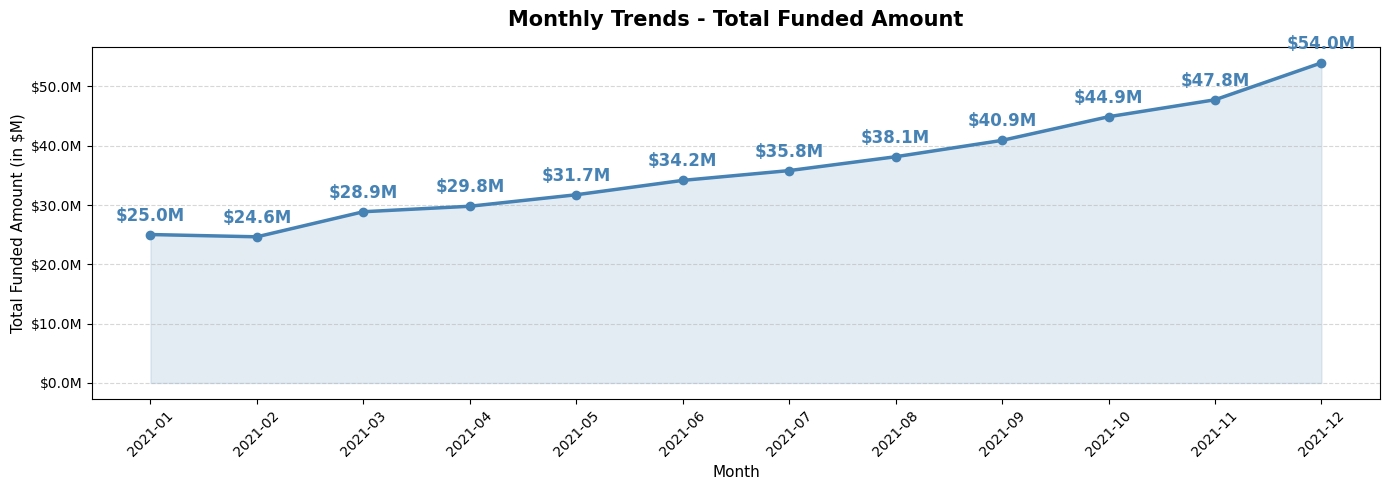

In [69]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Monthly Trends - Total Funded Amount
monthly_funded = (
    df.groupby(df['issue_date'].dt.to_period('M'))['loan_amount']
    .sum()
    .reset_index()
)
monthly_funded.columns = ['Month', 'Total_Funded_Amount']
monthly_funded['Month'] = monthly_funded['Month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_funded['Month'], monthly_funded['Total_Funded_Amount'] / 1e6,
        marker='o', linewidth=2.5, color='steelblue', markersize=6)
ax.fill_between(monthly_funded['Month'], monthly_funded['Total_Funded_Amount'] / 1e6,
                alpha=0.15, color='steelblue')

# ✅ Add Data Labels
for i, row in monthly_funded.iterrows():
    ax.annotate(
        f"${row['Total_Funded_Amount'] / 1e6:.1f}M",
        xy=(i, row['Total_Funded_Amount'] / 1e6),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center', fontsize=12, color='steelblue', fontweight='bold'
    )

ax.set_title('Monthly Trends - Total Funded Amount', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Funded Amount (in $M)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


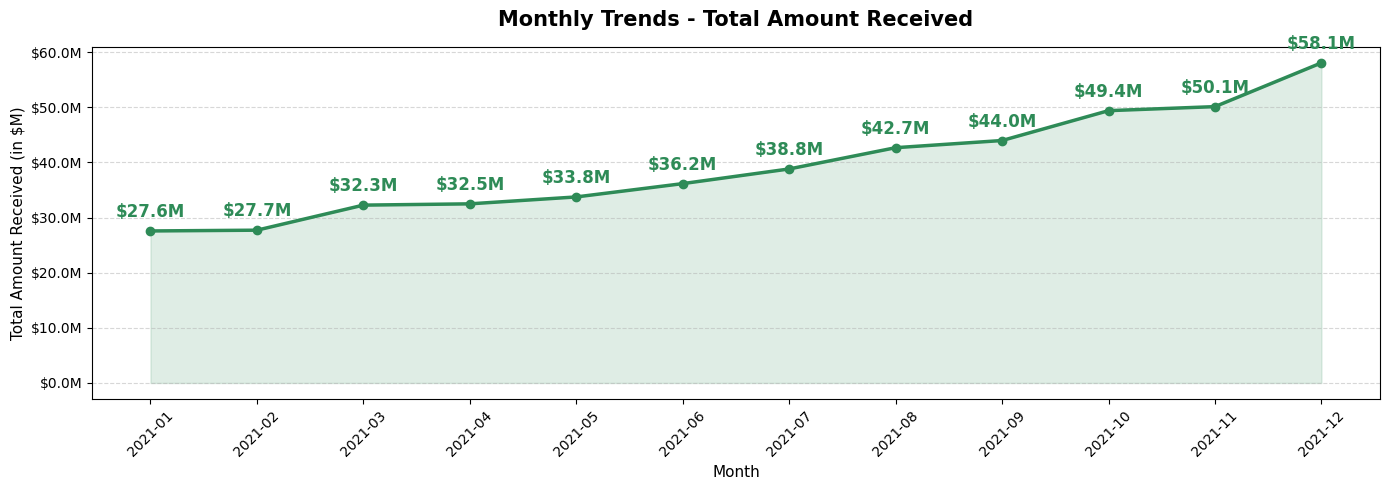

In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Monthly Trends - Total Amount Received
monthly_received = (
    df.groupby(df['issue_date'].dt.to_period('M'))['total_payment']
    .sum()
    .reset_index()
)
monthly_received.columns = ['Month', 'Total_Amount_Received']
monthly_received['Month'] = monthly_received['Month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_received['Month'], monthly_received['Total_Amount_Received'] / 1e6,
        marker='o', linewidth=2.5, color='seagreen', markersize=6)
ax.fill_between(monthly_received['Month'], monthly_received['Total_Amount_Received'] / 1e6,
                alpha=0.15, color='seagreen')

# Data Labels
for i, row in monthly_received.iterrows():
    ax.annotate(
        f"${row['Total_Amount_Received'] / 1e6:.1f}M",
        xy=(i, row['Total_Amount_Received'] / 1e6),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center', fontsize=12, color='seagreen', fontweight='bold'
    )

ax.set_title('Monthly Trends - Total Amount Received', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Amount Received (in $M)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


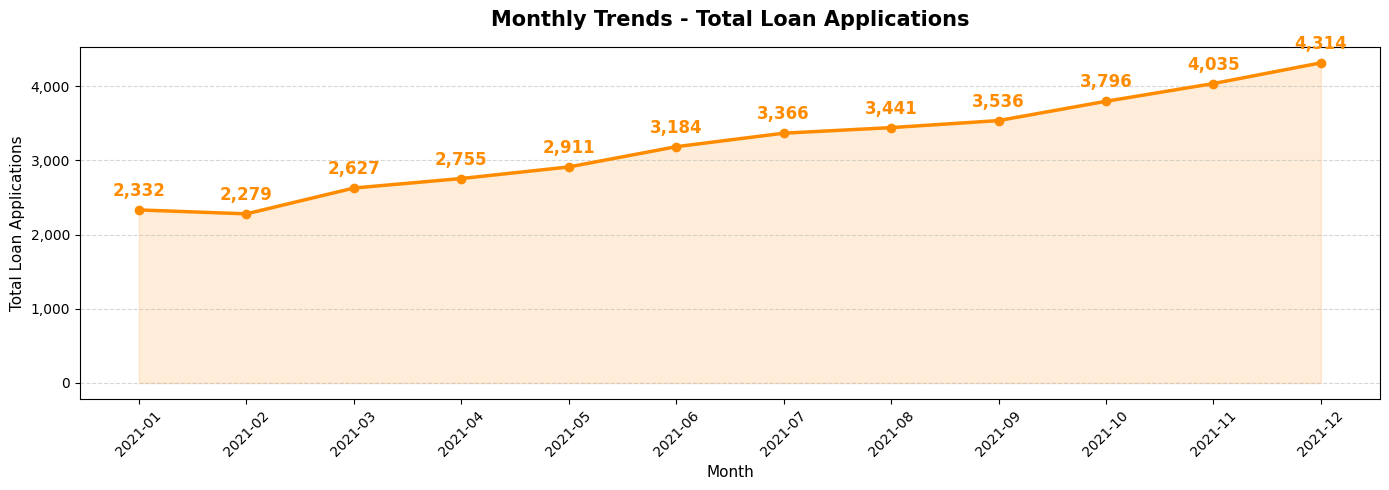

In [73]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Monthly Trends - Total Loan Applications
monthly_applications = (
    df.groupby(df['issue_date'].dt.to_period('M'))['id']
    .count()
    .reset_index()
)
monthly_applications.columns = ['Month', 'Total_Loan_Applications']
monthly_applications['Month'] = monthly_applications['Month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_applications['Month'], monthly_applications['Total_Loan_Applications'],
        marker='o', linewidth=2.5, color='darkorange', markersize=6)
ax.fill_between(monthly_applications['Month'], monthly_applications['Total_Loan_Applications'],
                alpha=0.15, color='darkorange')

# Data Labels
for i, row in monthly_applications.iterrows():
    ax.annotate(
        f"{int(row['Total_Loan_Applications']):,}",
        xy=(i, row['Total_Loan_Applications']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center', fontsize=12, color='darkorange', fontweight='bold'
    )

ax.set_title('Monthly Trends - Total Loan Applications', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Loan Applications', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


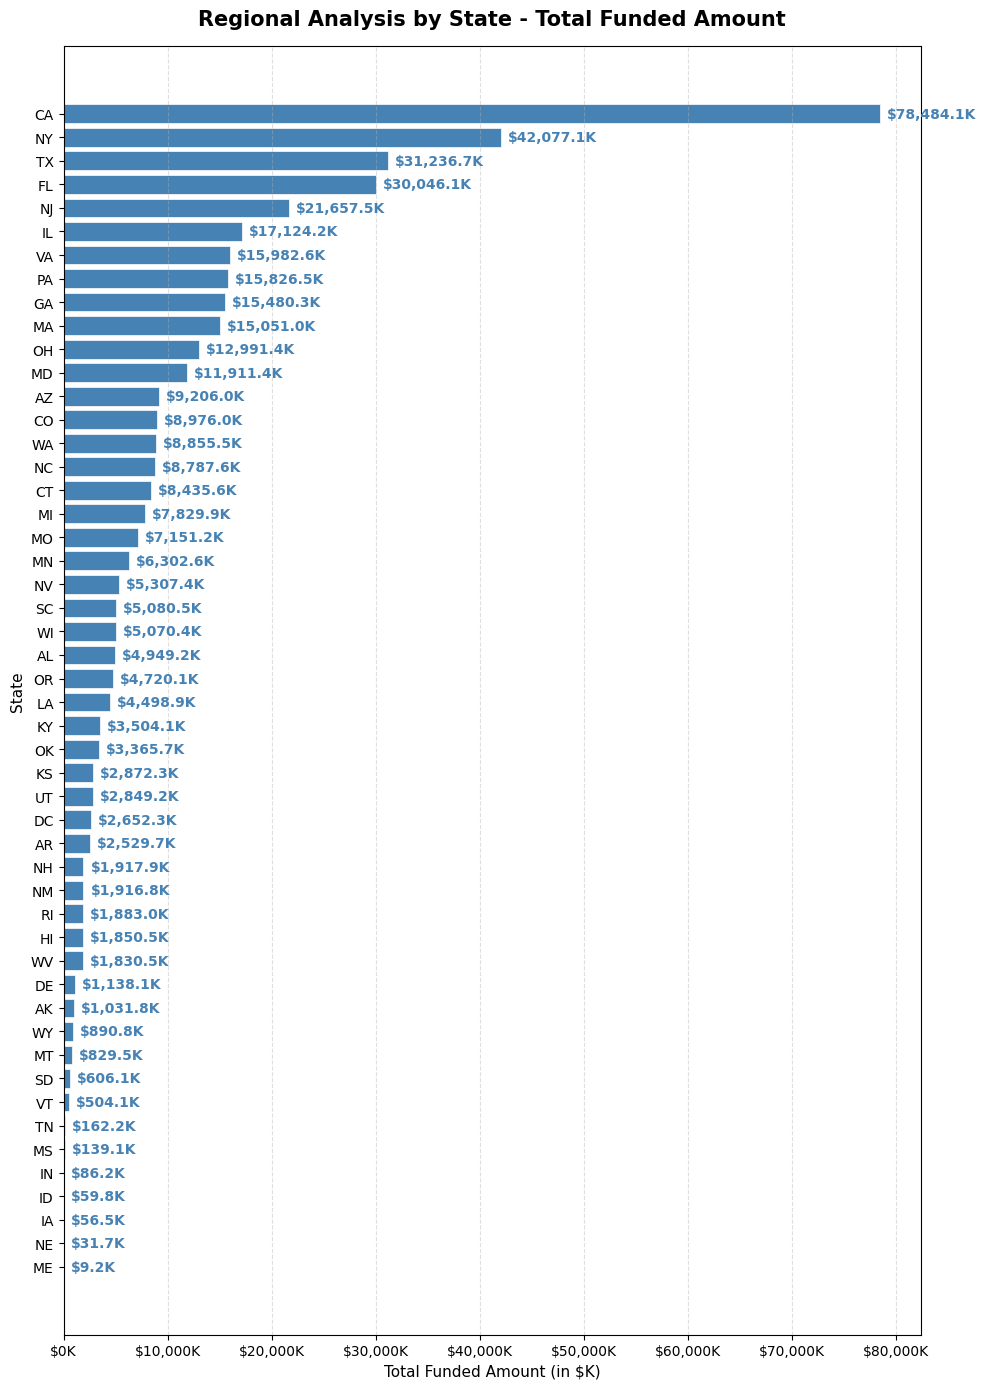

In [78]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Regional Analysis by State - Total Funded Amount
state_funded = (
    df.groupby('address_state')['loan_amount']
    .sum()
    .reset_index()
    .sort_values('loan_amount', ascending=True)
)
state_funded.columns = ['State', 'Total_Funded_Amount']

# Plot
fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(state_funded['State'], state_funded['Total_Funded_Amount'] / 1e3,
               color='steelblue', edgecolor='white', linewidth=0.5)

# Data Labels
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"${width:,.1f}K",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left', va='center', fontsize=10, color='steelblue', fontweight='bold'
    )

ax.set_title('Regional Analysis by State - Total Funded Amount', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('State', fontsize=11)
ax.set_xlabel('Total Funded Amount (in $K)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


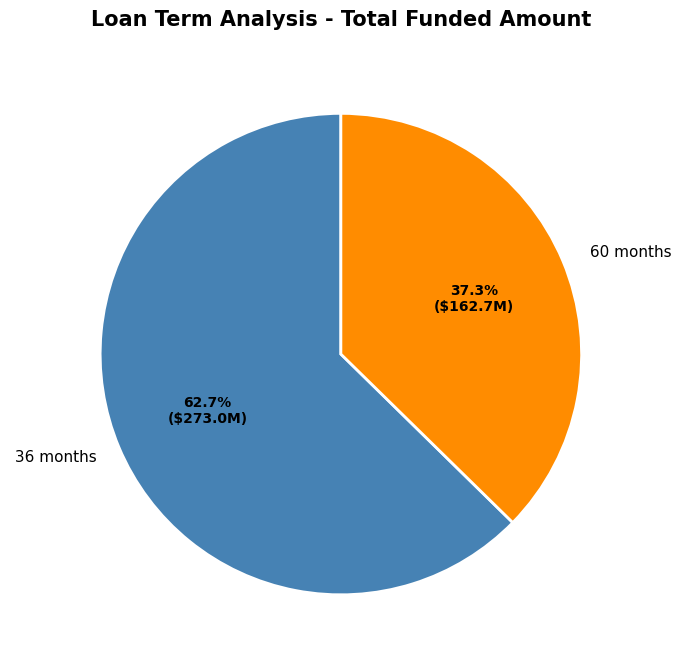

In [79]:
import matplotlib.pyplot as plt

# Loan Term Analysis - Total Funded Amount
term_funded = (
    df.groupby('term')['loan_amount']
    .sum()
    .reset_index()
)
term_funded.columns = ['Term', 'Total_Funded_Amount']

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    term_funded['Total_Funded_Amount'],
    labels=term_funded['Term'],
    autopct=lambda pct: f'{pct:.1f}%\n(${pct * term_funded["Total_Funded_Amount"].sum() / 100 / 1e6:.1f}M)',
    colors=['steelblue', 'darkorange'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)

# Style autotexts
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Loan Term Analysis - Total Funded Amount', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


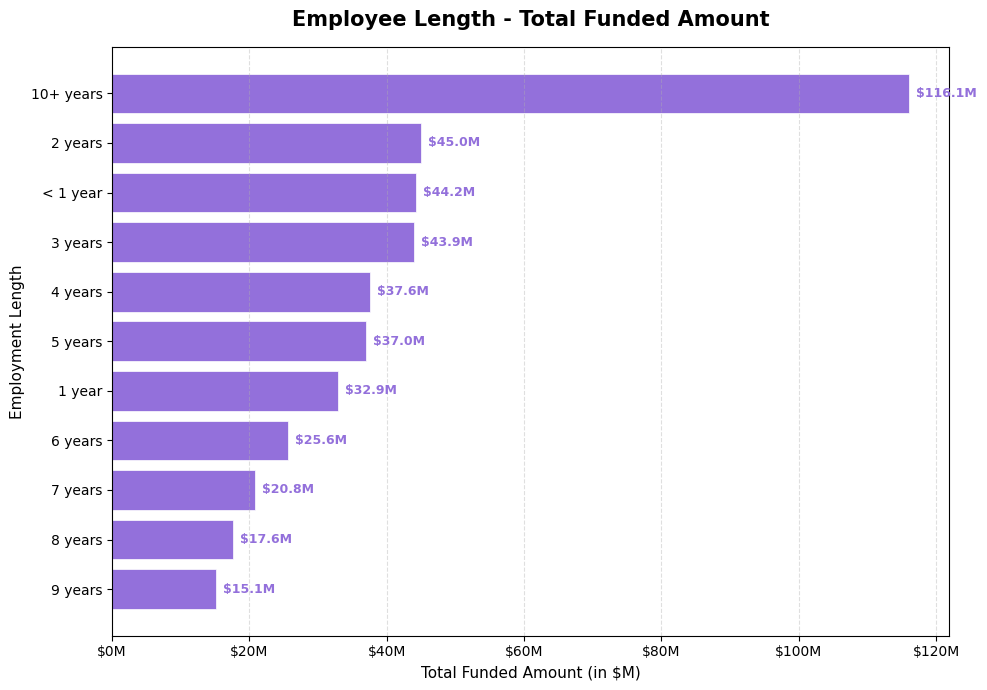

In [80]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Employee Length Analysis - Total Funded Amount
emp_funded = (
    df.groupby('emp_length')['loan_amount']
    .sum()
    .reset_index()
    .sort_values('loan_amount', ascending=True)
)
emp_funded.columns = ['Emp_Length', 'Total_Funded_Amount']

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(emp_funded['Emp_Length'], emp_funded['Total_Funded_Amount'] / 1e6,
               color='mediumpurple', edgecolor='white', linewidth=0.5)

# Data Labels
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"${width:.1f}M",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left', va='center', fontsize=9, color='mediumpurple', fontweight='bold'
    )

ax.set_title('Employee Length - Total Funded Amount', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Employment Length', fontsize=11)
ax.set_xlabel('Total Funded Amount (in $M)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fM'))
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


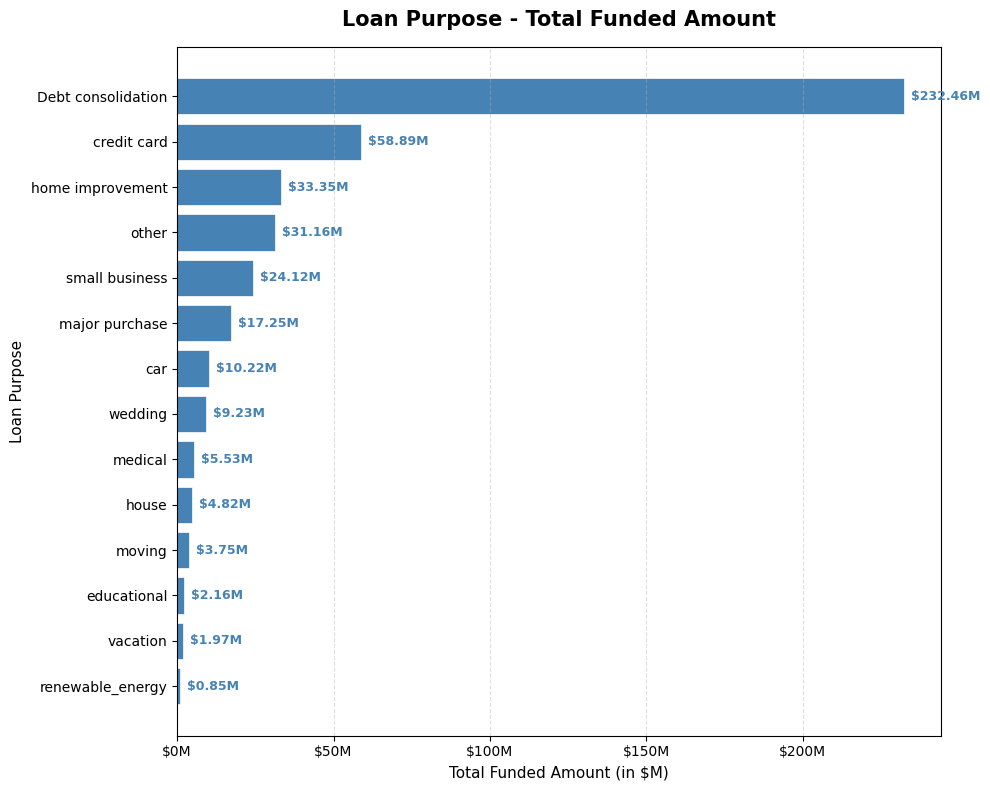

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Loan Purpose Analysis - Total Funded Amount
purpose_funded = (
    df.groupby('purpose')['loan_amount']
    .sum()
    .reset_index()
    .sort_values('loan_amount', ascending=True)
)
purpose_funded.columns = ['Purpose', 'Total_Funded_Amount']

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(purpose_funded['Purpose'], purpose_funded['Total_Funded_Amount'] / 1e6,
               color='steelblue', edgecolor='white', linewidth=0.5)

# Data Labels
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"${width:.2f}M",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left', va='center', fontsize=9, color='steelblue', fontweight='bold'
    )

ax.set_title('Loan Purpose - Total Funded Amount', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Loan Purpose', fontsize=11)
ax.set_xlabel('Total Funded Amount (in $M)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fM'))
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


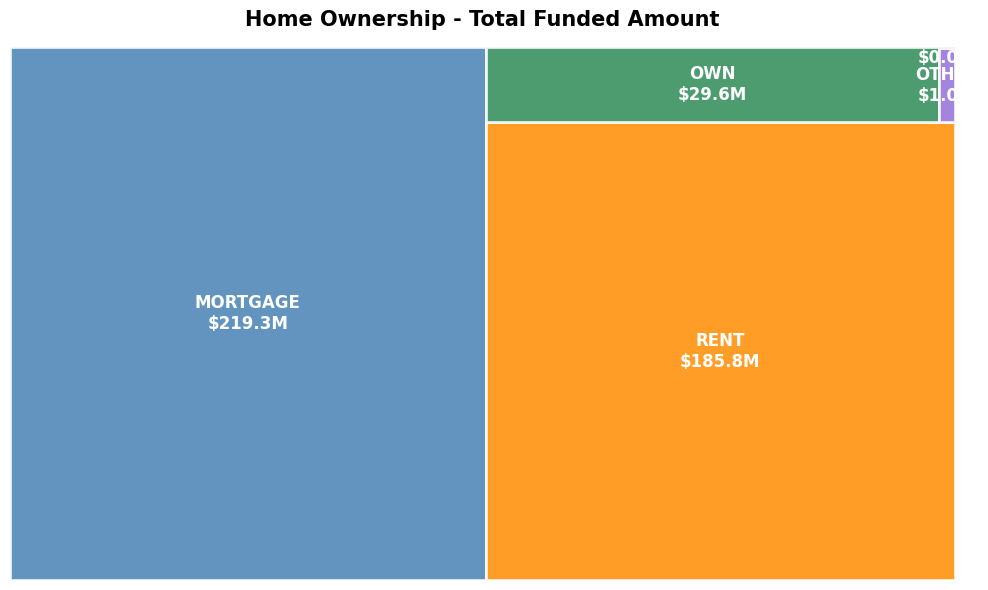

In [85]:
import matplotlib.pyplot as plt
import squarify  # pip install squarify

# Home Ownership Analysis - Total Funded Amount
home_funded = (
    df.groupby('home_ownership')['loan_amount']
    .sum()
    .reset_index()
    .sort_values('loan_amount', ascending=False)
)
home_funded.columns = ['Home_Ownership', 'Total_Funded_Amount']

# Labels with value
labels = [
    f"{row['Home_Ownership']}\n${row['Total_Funded_Amount']/1e6:.1f}M"
    for _, row in home_funded.iterrows()
]

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
squarify.plot(
    sizes=home_funded['Total_Funded_Amount'],
    label=labels,
    color=colors[:len(home_funded)],
    alpha=0.85,
    edgecolor='white',
    linewidth=2,
    text_kwargs={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'},
    ax=ax
)

ax.set_title('Home Ownership - Total Funded Amount', fontsize=15, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()
